In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
dir_name = '/content/drive/MyDrive/THESIS/Codes/[Base] CNN-LSTM/Commercial/'
df = pd.read_csv(f"{dir_name}Commercial_test_predictions.csv")
df.head()

,Date,Actual,Prediction
0,2020-09-01,1442931.0,1713556.4
1,2020-10-01,1491656.0,1677421.2
2,2020-11-01,1517727.0,1653579.9
3,2020-12-01,1405599.0,1619070.5
4,2021-01-01,1434401.0,1602620.5


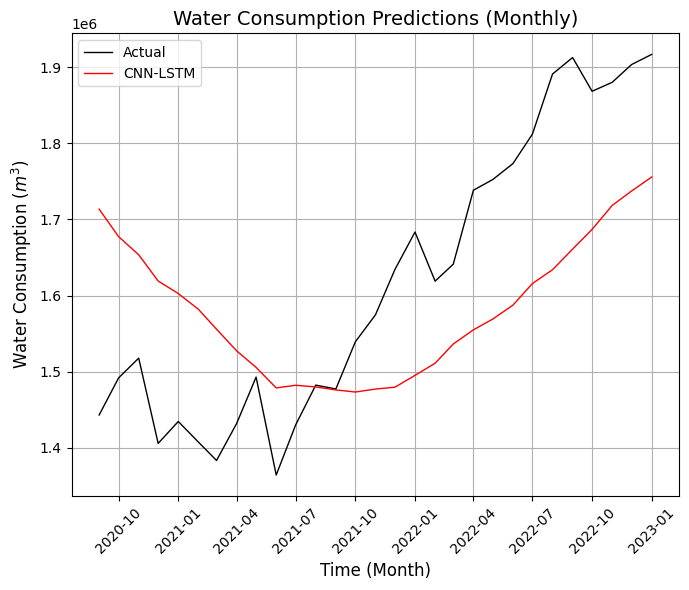

In [13]:
# Convert 'Date' to datetime for proper labeling
df['Date'] = pd.to_datetime(df['Date'])

# Plot the data
plt.figure(figsize=(7, 6))
plt.plot(df['Date'], df['Actual'], label='Actual', color='black', linewidth=1)
plt.plot(df['Date'], df['Prediction'], label='CNN-LSTM', color='red', linewidth=1)

# Customizing the plot
plt.title('Water Consumption Predictions (Monthly)', fontsize=14)
plt.xlabel('Time (Month)', fontsize=12)
plt.ylabel('Water Consumption ($m^3$)', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True)

# Rotate x-axis labels for better visibility
plt.xticks(rotation=45)

# Display the plot
plt.tight_layout()
plt.show()

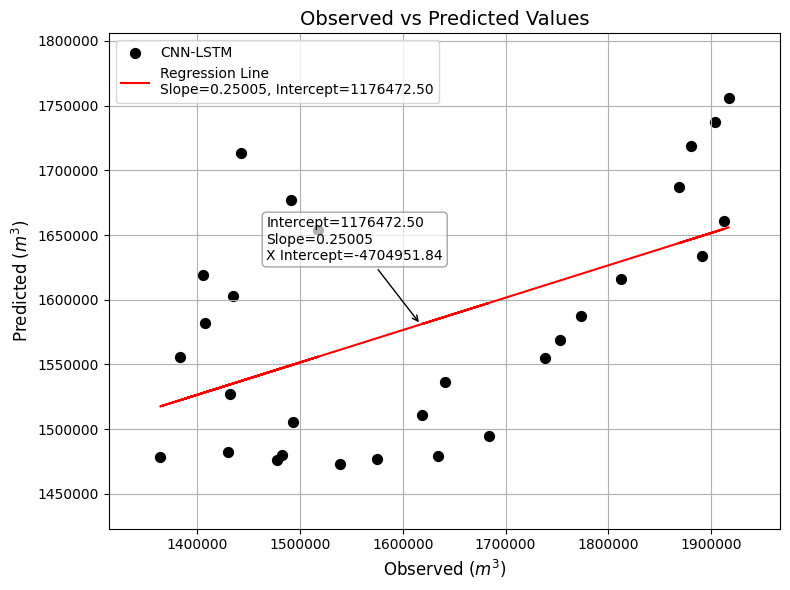

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Extract actual and predicted values
actual = df['Actual']
predicted = df['Prediction']

# Calculate the regression line
slope, intercept = np.polyfit(actual, predicted, 1)
regression_line = slope * actual + intercept

# Create the scatter plot with fixed figure size
plt.figure(figsize=(8, 6))
plt.scatter(actual, predicted, color='black', label='CNN-LSTM', s=50)

# Plot the regression line
plt.plot(actual, regression_line, color='red', label=f'Regression Line\nSlope={slope:.5f}, Intercept={intercept:.2f}')

# Add annotations at a clear location
plt.annotate(
    f"Intercept={intercept:.2f}\nSlope={slope:.5f}\nX Intercept={-intercept / slope:.2f}",
    xy=(actual.mean(), predicted.mean()),
    xytext=(actual.mean() - 150000, predicted.mean() + 50000),
    fontsize=10,
    color='black',
    bbox=dict(boxstyle="round,pad=0.3", edgecolor="gray", facecolor="white", alpha=0.7),
    arrowprops=dict(arrowstyle="->", color="black")
)

# Disable scientific notation on axes
plt.ticklabel_format(style='plain', axis='both')

# Customizing the plot
plt.title('Observed vs Predicted Values', fontsize=14)
plt.xlabel('Observed ($m^3$)', fontsize=12)
plt.ylabel('Predicted ($m^3$)', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True)

# Dynamically set axis limits to match data
plt.xlim(actual.min() - 50000, actual.max() + 50000)
plt.ylim(predicted.min() - 50000, predicted.max() + 50000)

# Display the plot
plt.tight_layout()
plt.show()
